In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial

PDK.activate()

In [2]:
def b_symmetric_body_vertices(L_mmi, W_mmi, W_narrow):
    return np.array(
        [
            #body mmi
            # parte abajo: mirar dibujo libreta
            (0.0,          -W_mmi / 2), #p1
            (L_mmi / 4,    -W_narrow / 2), #p2
            (L_mmi / 2,    -W_mmi / 2), #p3
            (3*L_mmi / 4,  -W_narrow / 2),
            (L_mmi,        -W_mmi / 2),

            # parte arriba: mirar dibujo libreta
            (L_mmi,         W_mmi / 2), #p6
            (3*L_mmi / 4,   W_narrow / 2),
            (L_mmi / 2,     W_mmi / 2),
            (L_mmi / 4,     W_narrow / 2),
            (0.0,           W_mmi / 2),
        ]
    )

import numpy as np


# -------------------------
# TAPERS IZQUIERDA
# -------------------------

def taper_bottom_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, -W_mmi / 2 + d_io),
            (0.0, -W_mmi / 2 + d_io + Wt),

            # lado estrecho, izquierda
            (-lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def taper_top_left_vertices(W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado ancho, conectado al MMI
            (0.0, W_mmi / 2 - d_io - Wt),
            (0.0, W_mmi / 2 - d_io),

            # lado estrecho, izquierda
            (-lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# TAPERS DERECHA
# -------------------------

def taper_bottom_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, -W_mmi / 2 + d_io),
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi, -W_mmi / 2 + d_io + Wt),
        ]
    )


def taper_top_right_vertices(L_mmi, W_mmi, lt, wt, Wt, d_io):
    return np.array(
        [
            # lado ancho, conectado al MMI
            (L_mmi, W_mmi / 2 - d_io - Wt),
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            # lado estrecho, derecha
            (L_mmi + lt, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi, W_mmi / 2 - d_io),
        ]
    )


# -------------------------
# GUÍAS IZQUIERDA
# -------------------------

def wg_bottom_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (-lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (-lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (-lt - L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_left_vertices(W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (-lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (-lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (-lt - L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )


# -------------------------
# GUÍAS DERECHA
# -------------------------

def wg_bottom_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
            (L_mmi + lt,        -W_mmi / 2 + d_io + Wt / 2 + wt / 2),
        ]
    )


def wg_top_right_vertices(L_mmi, W_mmi, L_wg, lt, wt, Wt, d_io):
    return np.array(
        [
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 - wt / 2),
            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 - wt / 2),

            (L_mmi + lt + L_wg, W_mmi / 2 - d_io - Wt / 2 + wt / 2),
            (L_mmi + lt,        W_mmi / 2 - d_io - Wt / 2 + wt / 2),
        ]
    )

In [ ]:
def b_symmetric_mmi_vertices(
    L_mmi,
    W_mmi,
    W_narrow,
    L_wg,
    lt,
    wt,
    Wt,
    d_io,
):
    return {
        "mmi": b_symmetric_body_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            W_narrow=W_narrow,
        ),

        "in_bot_taper": taper_bottom_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_taper": taper_top_left_vertices(
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_taper": taper_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_taper": taper_top_right_vertices(

            L_mmi=L_mmi,
            W_mmi=W_mmi,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_bot_wg": wg_bottom_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "in_top_wg": wg_top_left_vertices(
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_bot_wg": wg_bottom_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),

        "out_top_wg": wg_top_right_vertices(
            L_mmi=L_mmi,
            W_mmi=W_mmi,
            L_wg=L_wg,
            lt=lt,
            wt=wt,
            Wt=Wt,
            d_io=d_io,
        ),
    }

2026-05-29 11:51:14.937 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3003311191.oas'


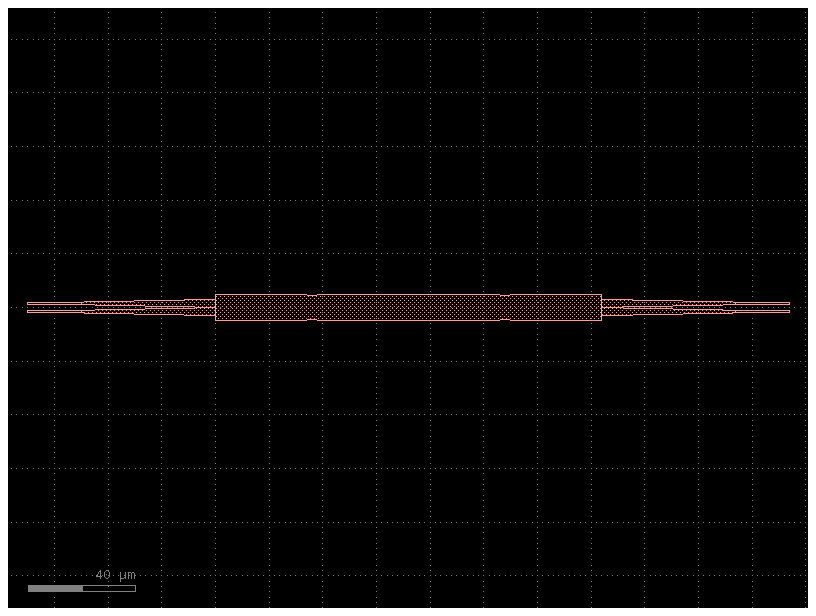

In [6]:


L_mmi = 144
W_mmi = 10
W_narrow = 10-0.72
L_wg = 20
lt = 50
wt = 1.0
Wt = 3
d_io = 1.97

polys = b_symmetric_mmi_vertices(
    L_mmi=L_mmi,
    W_mmi=W_mmi,
    W_narrow=W_narrow,
    L_wg=L_wg,
    lt=lt,
    wt=wt,
    Wt=Wt,
    d_io=d_io,
)

c = gf.Component()
for poly in polys.values():
    c.add_polygon(poly, layer="WG")

c.plot()
c.show()

107.23664504929738
2026-05-27 09:35:50.979 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/614834259.oas'


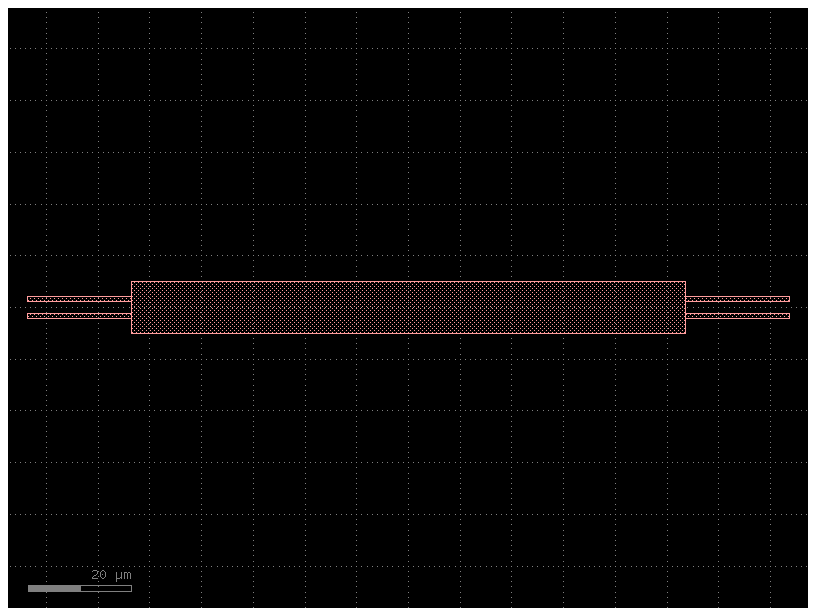

In [32]:
import numpy as np
mmi = gf.Component()

L_pi_mmi = 150.43
W_mmi = 10
d0 = (2/np.pi)* np.arccos(np.sqrt(0.95))
dW = W_mmi * d0
deltaW = 1 - 2*dW/W_mmi
L_mmi = deltaW * (1/3)* 3*L_pi_mmi
wg_length = 20
wg_width = 1
B = mmi <<  gf.components.rectangle((L_mmi, W_mmi))

mmi.dmove((-L_mmi/2, -W_mmi/2))


I1 = mmi << gf.components.rectangle((20, 1))
I2 = mmi << gf.components.rectangle((20, 1))
O1= mmi << gf.components.rectangle((20, 1))
O2 = mmi << gf.components.rectangle((20, 1))


I1.dmove((-L_mmi/2 - wg_length, -W_mmi*(1/6) - wg_width/2 ) )
I2.dmove((-L_mmi/2 - wg_length, W_mmi*(1/6) - wg_width/2) )
O1.dmove((L_mmi/2, -W_mmi*(1/6) - wg_width/2) )
O2.dmove((L_mmi/2, W_mmi*(1/6) - wg_width/2) )


mmi.plot()
mmi.show()
mmi.flatten(True)
mmi.write("no_tapersf_si.gds")
print(L_mmi)

2026-05-27 10:08:34.845 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/657855108.oas'
150.43


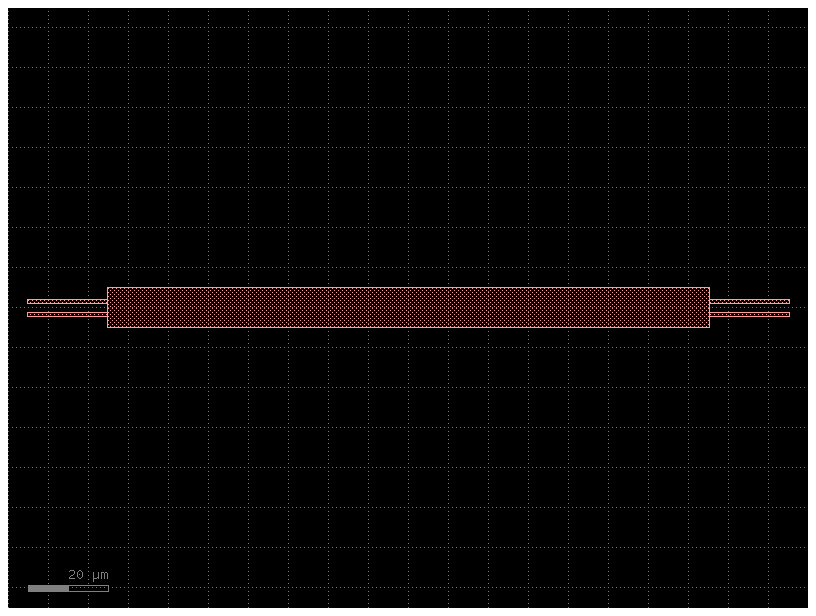

In [34]:
mmi = gf.Component()

L_pi_mmi = 150.43
W_mmi = 10
d0 = (2/np.pi)* np.arccos(np.sqrt(0.95))
dW = W_mmi * d0
deltaW = 1 - 2*dW/W_mmi
#L_mmi = deltaW * (1/3)* 3*L_pi_mmi
L_mmi = L_pi_mmi
wg_length = 20
wg_width = 1
B = mmi <<  gf.components.rectangle((L_mmi, W_mmi))

mmi.dmove((-L_mmi/2, -W_mmi/2))


I1 = mmi << gf.components.rectangle((20, 1))
I2 = mmi << gf.components.rectangle((20, 1))
O1= mmi << gf.components.rectangle((20, 1))
O2 = mmi << gf.components.rectangle((20, 1))


I1.dmove((-L_mmi/2 - wg_length, -W_mmi*(1/6) - wg_width/2 ) )
I2.dmove((-L_mmi/2 - wg_length, W_mmi*(1/6) - wg_width/2) )
O1.dmove((L_mmi/2, -W_mmi*(1/6) - wg_width/2) )
O2.dmove((L_mmi/2, W_mmi*(1/6) - wg_width/2) )


mmi.plot()
mmi.show()
mmi.flatten(True)
mmi.write("no_tapers_pi.gds")
print(L_mmi)

2026-05-27 12:39:40.163 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/3677549533.oas'


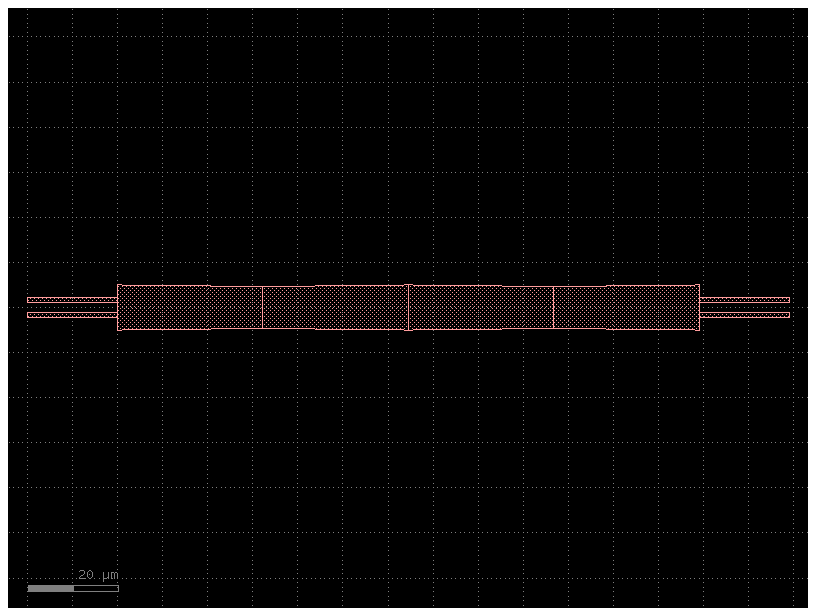

In [74]:
mmi = gf.Component()
L_mmi = 128.97
dW = 0.72
W_mmi_dw = W_mmi - dW
wg_length = 20
wg_width = 1
B1 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B2 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B3 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B4 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
I1 = mmi << gf.components.rectangle((20, 1))
I2 = mmi << gf.components.rectangle((20, 1))
O1= mmi << gf.components.rectangle((20, 1))
O2 = mmi << gf.components.rectangle((20, 1))


B2.dmirror_x()
B2.dmovex(L_mmi/2)
B3.dmovex(L_mmi/2)
B4.dmirror_x()
B4.dmovex(L_mmi)

I1.dmove((- wg_length, -W_mmi*(1/6) - wg_width/2 ) )
I2.dmove(( - wg_length, W_mmi*(1/6) - wg_width/2) )
O1.dmove((L_mmi, -W_mmi*(1/6) - wg_width/2) )
O2.dmove((L_mmi, W_mmi*(1/6) - wg_width/2) )

mmi.plot()
mmi.show()

mmi.flatten(True)
mmi.write("bsym_notap.gds")


2026-05-27 15:38:17.515 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/4063504727.oas'


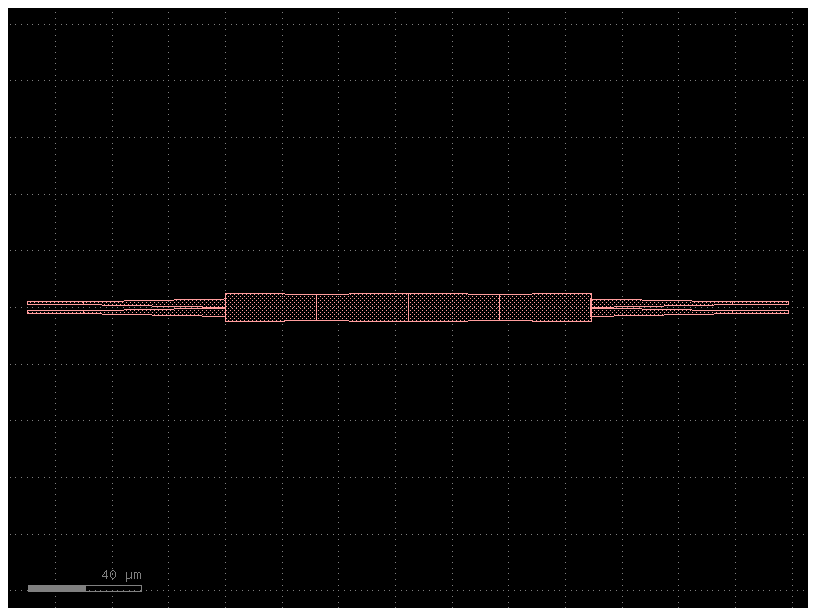

In [90]:
mmi = gf.Component()

W_mmi = 10
d0 = (2/np.pi)* np.arccos(np.sqrt(0.95))
dW = W_mmi*d0
deltaW = 1 - 2*dW/W_mmi
L_mmi = deltaW * (1/3)* 3*L_pi_mmi
L_mmi = 128.97
dW = 0.72
W_mmi_dw = W_mmi - dW

wg_length = 20
wg_width = 1

lt = 50.0 # um, taper length
Wt = 3.0 #taper width at mmi interface
wt = 1 # access wvg 

B1 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B2 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B3 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B4 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
T1 = mmi << gf.components.taper(lt, wg_width, Wt)
T2 = mmi << gf.components.taper(lt, wg_width, Wt)
T3 = mmi << gf.components.taper(lt, wg_width, Wt)
T4 = mmi << gf.components.taper(lt, wg_width, Wt)
I1 = mmi << gf.components.rectangle((20, 1))
I2 = mmi << gf.components.rectangle((20, 1))
O1= mmi << gf.components.rectangle((20, 1))
O2 = mmi << gf.components.rectangle((20, 1))


B2.dmirror_x()
B2.dmovex(L_mmi/2)
B3.dmovex(L_mmi/2)
B4.dmirror_x()
B4.dmovex(L_mmi)

'''
I1.dmove((- wg_length, -W_mmi*(1/6) - wg_width/2 ) )
I2.dmove(( - wg_length, W_mmi*(1/6) - wg_width/2) )
O1.dmove((L_mmi, -W_mmi*(1/6) - wg_width/2) )
O2.dmove((L_mmi, W_mmi*(1/6) - wg_width/2) )
'''
T1.dmove((- lt, -W_mmi*(1/6) ) )
T2.dmove((- lt, W_mmi*(1/6) ) )
T3.dmirror_x()
T3.dmove((L_mmi + lt, -W_mmi*(1/6) ) )
T4.dmirror_x()
T4.dmove((L_mmi + lt, W_mmi*(1/6) ) )



I1.dmove((- wg_length - lt, -W_mmi*(1/6) - wg_width/2 ) )
I2.dmove(( - wg_length -lt, W_mmi*(1/6) - wg_width/2) )
O1.dmove((L_mmi + lt, -W_mmi*(1/6) - wg_width/2) )
O2.dmove((L_mmi + lt, W_mmi*(1/6) - wg_width/2) )

mmi.plot()
mmi.show()

mmi.flatten(True)
mmi.write("bsym_tap.gds")


2026-05-27 16:21:40.443 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/TFG/build/oas/2109661011.oas'


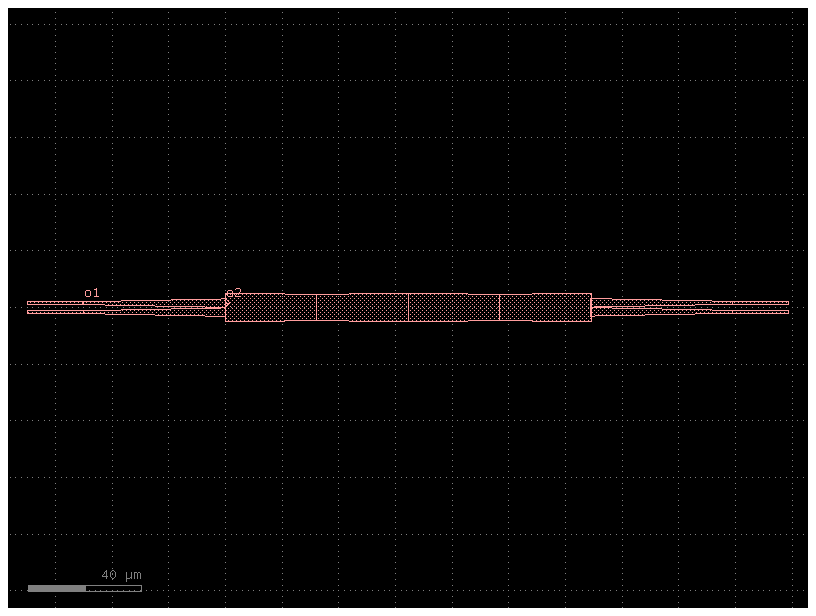

In [19]:
import numpy as np
mmi = gf.Component()

L_pi_mmi = 150.43
W_mmi = 10
d0 = (2/np.pi)* np.arccos(np.sqrt(0.95))
dW = W_mmi*d0
deltaW = 1 - 2*dW/W_mmi
L_mmi = deltaW * (1/3)* 3*L_pi_mmi
L_mmi = 128.97
dW = 0.72
W_mmi_dw = W_mmi - dW

wg_length = 20
wg_width = 1

lt = 50.0 # um, taper length
Wt = 3.0 #taper width at mmi interface
wt = 1 # access wvg 

B1 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B2 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B3 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
B4 = mmi << gf.components.taper(L_mmi/4, W_mmi, W_mmi_dw)
T1 = mmi << gf.components.taper(lt, wg_width, Wt)
T2 = mmi << gf.components.taper(lt, wg_width, Wt)
T3 = mmi << gf.components.taper(lt, wg_width, Wt)
T4 = mmi << gf.components.taper(lt, wg_width, Wt)
I1 = mmi << gf.components.rectangle((20, 1))
I2 = mmi << gf.components.rectangle((20, 1))
O1= mmi << gf.components.rectangle((20, 1))
O2 = mmi << gf.components.rectangle((20, 1))


B2.dmirror_x()
B2.dmovex(L_mmi/2)
B3.dmovex(L_mmi/2)
B4.dmirror_x()
B4.dmovex(L_mmi)

T1.dmove((- lt, W_mmi/2 - 1.97 -Wt/2 ) )
T2.dmove((- lt, -W_mmi/2 + 1.97 +Wt/2 ) )
T3.dmirror_x()
T3.dmove((L_mmi + lt, -W_mmi/2 + 1.97 +Wt/2 ) )
T4.dmirror_x()
T4.dmove((L_mmi + lt, W_mmi/2 - 1.97 -Wt/2  ) )

I1.dmove((T1.ports['o1'].dx - wg_length, T1.ports['o1'].dy  - wg_width/2) )
I2.dmove((T2.ports['o1'].dx - wg_length, T2.ports['o1'].dy  - wg_width/2) )
O1.dmove((T3.ports['o1'].dx , T3.ports['o1'].dy  - wg_width/2) )
O2.dmove((T4.ports['o1'].dx , T4.ports['o1'].dy  - wg_width/2) )

mmi.add_ports(T1)
mmi.draw_ports()
mmi.plot()
mmi.show()

mmi.flatten(True)
mmi.write("bsym_tap_57geom.gds")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
from tidy3d.plugins.mode import ModeSolver

In [4]:
# Longitud de onda
lambda0 = 1.55  # um
freq0 = td.C_0 / lambda0
freqs = [freq0]

# Índices
n_air = 1.0
n_sio2 = 1.444
n_sin = 2.0  # cambia por tu valor real

air = td.Medium(permittivity=n_air**2)
sio2 = td.Medium(permittivity=n_sio2**2)
sin = td.Medium(permittivity=n_sin**2)

# Geometría del MMI
W_mmi = 10.0      # um, cambia por tu valor
h_core = 0.3     # um, cambia por tu valor

# Dominio transversal
buffer_y = 2.0
air_above = 2.5
sub_thick = 2.0

Ly = W_mmi + 2 * buffer_y
bottom_buffer = 0.5  # um

z_min = -h_core / 2 - sub_thick - bottom_buffer
z_max =  h_core / 2 + air_above

Lz = z_max - z_min
z_center = 0.5 * (z_min + z_max)

In [5]:
# Longitud ficticia en x: da igual para el modo solver,
# porque resolveremos un plano x = constante
Lx = 1.0

substrate = td.Structure(
    geometry=td.Box(
        center=(0, 0, -h_core / 2 - sub_thick / 2),
        size=(td.inf, td.inf, sub_thick),
    ),
    medium=sio2,
)

mmi_core = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(td.inf, W_mmi, h_core),
    ),
    medium=sin,
)

sim_cross_section = td.Simulation(
    center=(0, 0, z_center),
    size=(Lx, Ly, Lz),
    medium=air,
    structures=[substrate, mmi_core],
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=30,
        wavelength=lambda0,
    ),
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)

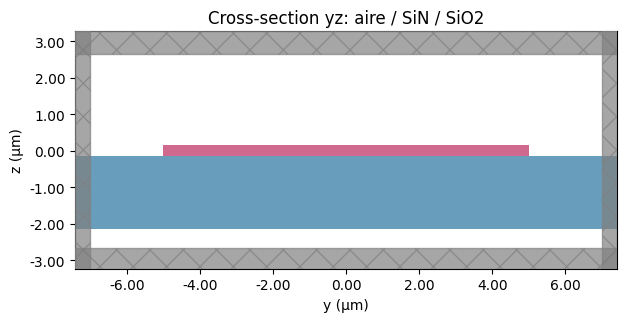

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

sim_cross_section.plot(
    x=0,
    ax=ax
)

ax.set_title("Cross-section yz: aire / SiN / SiO2")
ax.set_xlabel("y (µm)")
ax.set_ylabel("z (µm)")
ax.set_aspect("equal")

plt.show()

In [6]:
size=(0, Ly, Lz)
mode_spec = td.ModeSpec(
    num_modes=40,
    target_neff=n_sin,
)

mode_solver = ModeSolver(
    simulation=sim_cross_section,
    plane=td.Box(
        center=(0, 0, 0),
        size=(0, Ly, Lz),
    ),
    mode_spec=mode_spec,
    freqs=freqs,
)

mode_data = mode_solver.solve()

16:14:07 CEST WARNING: Use the remote mode solver with subpixel averaging for   
              better accuracy through 'tidy3d.web.run(...)' or the deprecated   
              'tidy3d.plugins.mode.web.run(...)'.                               


/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

16:14:28 CEST WARNING: Mode field at frequency index 0, mode index 17 does not  
              decay at the plane boundaries.                                    
              decay at the plane boundaries.                                    


In [7]:
neff = np.squeeze(mode_data.n_eff.isel(f=0).values)

print("Índices efectivos:")
for i, n in enumerate(neff):
    print(f"modo {i}: n_eff = {np.real(n):.6f}")

n0 = np.real(neff[0])
n1 = np.real(neff[1])

Lpi = lambda0 / (2 * (n0 - n1))

print()
print(f"n0 - n1 = {n0 - n1:.6e}")
print(f"Lpi = {Lpi:.4f} um")

Índices efectivos:
modo 0: n_eff = 1.652171
modo 1: n_eff = 1.646859
modo 2: n_eff = 1.637971
modo 3: n_eff = 1.625458
modo 4: n_eff = 1.609249
modo 5: n_eff = 1.589252
modo 6: n_eff = 1.565353
modo 7: n_eff = 1.537423
modo 8: n_eff = 1.505337
modo 9: n_eff = 1.476209
modo 10: n_eff = 1.470866
modo 11: n_eff = 1.469146
modo 12: n_eff = 1.461818
modo 13: n_eff = 1.449656
modo 14: n_eff = 1.433657
modo 15: n_eff = 1.428885
modo 16: n_eff = 1.414333
modo 17: n_eff = 1.406355
modo 18: n_eff = 1.404838
modo 19: n_eff = 1.397829
modo 20: n_eff = 1.394911
modo 21: n_eff = 1.392384
modo 22: n_eff = 1.384504
modo 23: n_eff = 1.382409
modo 24: n_eff = 1.380158
modo 25: n_eff = 1.374064
modo 26: n_eff = 1.372909
modo 27: n_eff = 1.369597
modo 28: n_eff = 1.366419
modo 29: n_eff = 1.363312
modo 30: n_eff = 1.355310
modo 31: n_eff = 1.353274
modo 32: n_eff = 1.348113
modo 33: n_eff = 1.342209
modo 34: n_eff = 1.337022
modo 35: n_eff = 1.327200
modo 36: n_eff = 1.325363
modo 37: n_eff = 1.325048
mod

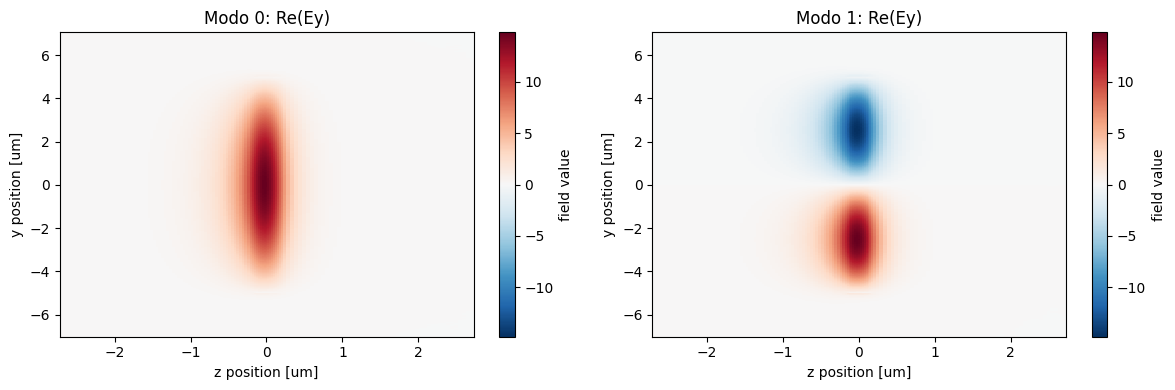

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

mode_data.Ey.isel(f=0, mode_index=0).real.plot(ax=ax[0])
ax[0].set_title("Modo 0: Re(Ey)")

mode_data.Ey.isel(f=0, mode_index=1).real.plot(ax=ax[1])
ax[1].set_title("Modo 1: Re(Ey)")

plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)

/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/TFG/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:4

2026-05-28 16:25:51.651 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_fcbf6861dee3ecf0.npz.
Fracción TE: [0.99998437 0.99993597]


array([1.62897964+5.60394545e-05j, 1.62362391+5.63018095e-05j])

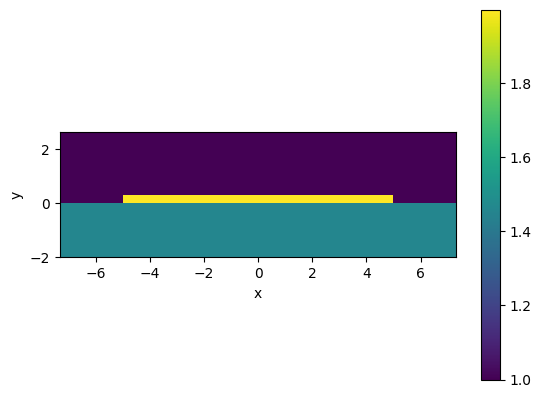

In [14]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    box_thickness = 2,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material= 1, # Surrounding material
    box_material = 'sio2',
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.45, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [15]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

144.70487546699283
